# Event Detection with `flovopy.processing.detection`

This notebook refactors the older **200 event detection** workflow so it uses
`flovopy` rather than the legacy `vsmTools` helpers.

## What changed

The original notebook used a `vsmTools` catalog object built from network
triggers. In this updated version, the workflow is **dataframe-first**:

- waveform retrieval still uses the ObsPy SDS client
- single-trace STA/LTA inspection still uses ObsPy's core trigger tools
- network event detection uses `flovopy.processing.detection`
- detected events are stored in a **pandas DataFrame**
- event windows can be exported to MiniSEED and PNG using flovopy helpers
- catalogue summaries and event-rate plots are generated directly from the dataframe

This makes the workflow easier to inspect, filter, save, and reuse in later
notebooks.


## 1. Imports and paths


In [1]:

from pathlib import Path
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------
sys.path.append("../week8")  # this is where set_samba_data_root.py lives
from set_samba_data_root import DATA_ROOT  # noqa: E402
LOCAL_DATA_DIR = Path("~").expanduser() / "compsci"
SDS_DIR = DATA_ROOT / "SDS_MVO"
EVENTS_DIR = LOCAL_DATA_DIR / "events"
CATALOG_DIR = LOCAL_DATA_DIR / "catalogs"

EVENTS_DIR.mkdir(parents=True, exist_ok=True)
CATALOG_DIR.mkdir(parents=True, exist_ok=True)


## 2. Import the flovopy detection tools

This notebook assumes `flovopy` is installed in your active environment. For
development workflows, the usual pattern is something like:

```bash
pip install -e /path/to/flovopy
```

If needed, you can also append a local repository path below.


In [2]:

# Optional: uncomment and edit if flovopy is not already importable
# sys.path.append("/path/to/flovopy")

from flovopy.processing.detection import (
    detect_network_event,
    extract_triggers_to_dataframe,
    export_events_from_catalogue,
    filter_events_df,
    plot_event_rate,
    plot_stream_with_event_markers,
    real_time_optimization,
    run_coincidence_trigger_dataframe,
)


## 3. Detection parameters

These values follow the broad-event settings you were already using in the old
notebook. The `real_time_optimization()` helper gives a reasonable starting
point for broad event classes.


In [3]:

# Suggested broad-band real-time parameters
sta_secs, lta_secs, thresh_on, thresh_off_ratio, freqmin, freqmax, corners = real_time_optimization("all")

# In the original notebook, threshOFF was used as an absolute value (1.2),
# not the normalized ratio returned by real_time_optimization().
thresh_off = 1.2

thresh_stations = 3
max_secs = 120.0
pretrig = 10.0
posttrig = 20.0

print(f"STA = {sta_secs:.2f} s")
print(f"LTA = {lta_secs:.2f} s")
print(f"Trigger ON = {thresh_on:.2f}")
print(f"Trigger OFF = {thresh_off:.2f}")
print(f"Bandpass = {freqmin:.1f}–{freqmax:.1f} Hz")
print(f"Minimum coincident channels = {thresh_stations}")


STA = 2.30 s
LTA = 11.50 s
Trigger ON = 2.40
Trigger OFF = 1.20
Bandpass = 1.5–12.0 Hz
Minimum coincident channels = 3


## 4. Small helper functions

These helpers keep the later notebook cells compact and readable.


In [ ]:
def drop_short_traces(st, min_seconds):
    """Remove traces that are too short to support the chosen trigger length."""
    st_out = st.copy()
    for tr in list(st_out):
        min_npts = min_seconds * tr.stats.sampling_rate
        if tr.stats.npts < min_npts:
            st_out.remove(tr)
    return st_out

def preprocess_detection_stream(st, freqmin, freqmax, corners=3, starttime=None, endtime=None):
    """Basic preprocessing for network event detection."""
    st2 = st.copy()
    if len(st2):
        try:
            st2.detrend("linear")
        except:
            st2.split()
            st2.detrend()
            st2.merge(fill_value=0.0)
        st2.taper(max_percentage=0.01, type="cosine")
        st2.filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=corners)
        if starttime and endtime:
            st2.trim(starttime=starttime, endtime=endtime)
    return st2

def detect_events_for_window(
    st,
    threshold_on,
    threshold_off,
    sta_seconds,
    lta_seconds,
    min_channels,
    pretrigger_seconds,
    posttrigger_seconds,
    outdir,
    write_mseed=False,
):
    if len(st) == 0:
        return pd.DataFrame()

    bad = []
    for tr in st:
        nlta = int(round(tr.stats.sampling_rate * lta_seconds))
        if tr.stats.npts < nlta:
            bad.append((tr.id, tr.stats.npts, nlta))

    if bad:
        print("[WARN] Short traces found before trigger:")
        for tr_id, npts, nlta in bad:
            print(f"  {tr_id}: npts={npts}, nlta={nlta}")
        # Return null dataframe rather than dying
        return pd.DataFrame()

    df = run_coincidence_trigger_dataframe(
        st,
        trigger_type="classicstalta",
        sta_seconds=sta_seconds,
        lta_seconds=lta_seconds,
        threshold_on=threshold_on,
        threshold_off=threshold_off,
        min_channels=min_channels,
        pretrigger_seconds=pretrigger_seconds,
        posttrigger_seconds=posttrigger_seconds,
        write_mseed=write_mseed,
        outdir=str(outdir),
        make_plots=False,
        filename_safe=True,
        details=True,
        max_trigger_length=max_secs,
        debug_on_short_trace=False,
    )
    return df

def summarize_detection_df(df):
    """Print a concise summary of an event dataframe."""
    if df is None or len(df) == 0:
        print("No events detected.")
        return
    print(f"Detected {len(df)} events")
    cols = [c for c in ['on_time', 'off_time', 'duration_s', 'coincidence_sum', 'snr_rms', 'n_seed_ids'] if c in df.columns]
    display(df[cols].head())


## 5. Inspect a few hours of data

A dayplot is still a good way to pick sensible trigger parameters before doing
larger batch detection.


In [5]:
# ------------------------------------------------------------------
# SDS archive client
# ------------------------------------------------------------------
#from obspy.clients.filesystem.sds import Client
from flovopy.enhanced.sdsclient import EnhancedSDSClient

sdsclient = EnhancedSDSClient(str(SDS_DIR))

help(sdsclient.get_nslc_for_day)
sdsclient.get_nslc_for_day(obspy.UTCDateTime(2003,7,11))

help(sdsclient.get_availability)
sdsclient.get_availability(startday=obspy.UTCDateTime(2003,7,11), endday=obspy.UTCDateTime(2003,7,13))

Help on method get_nslc_for_day in module flovopy.enhanced.sdsclient:

get_nslc_for_day(day: 'UTCDateTime', skip_low_rate: 'bool' = True) -> 'Set[Tuple[str, str, str, str]]' method of flovopy.enhanced.sdsclient.EnhancedSDSClient instance
    Return NSLC tuples available on a given UTC day.

    Tries ObsPy discovery first, then falls back to walking the SDS tree.

Help on method get_availability in module flovopy.enhanced.sdsclient:

get_availability(startday: 'UTCDateTime', endday: 'UTCDateTime', trace_ids: 'Optional[Sequence[str]]' = None, skip_low_rate_channels: 'bool' = True, progress: 'bool' = True, verbose: 'bool' = False) -> 'tuple[pd.DataFrame, List[str]]' method of flovopy.enhanced.sdsclient.EnhancedSDSClient instance
    Return a wide day-by-trace availability table using only
    ObsPy's ``get_availability_percentage()``.

    Parameters
    ----------
    startday, endday
        UTC day range. Rows are produced from ``startday`` up to but not
        including ``endday``.


Availability: 100%|██████████| 2/2 [00:08<00:00,  4.25s/it]


(         date  MV.MBGB..BHZ  MV.MBGH..BHZ  MV.MBLG..SHZ  MV.MBLY..HHZ  \
 0  2003-07-11           1.0           1.0           1.0           1.0   
 1  2003-07-12           1.0           1.0           1.0           1.0   
 
    MV.MBRV..SHZ  MV.MBRY..BHZ  MV.MBSS..SHZ  MV.MBWH..SHZ  
 0           1.0           1.0           1.0           1.0  
 1           1.0           1.0           1.0           1.0  ,
 ['MV.MBGB..BHZ',
  'MV.MBGH..BHZ',
  'MV.MBLG..SHZ',
  'MV.MBLY..HHZ',
  'MV.MBRV..SHZ',
  'MV.MBRY..BHZ',
  'MV.MBSS..SHZ',
  'MV.MBWH..SHZ'])

In [6]:
help(sdsclient.get_waveforms)

Help on method get_waveforms in module flovopy.enhanced.sdsclient:

get_waveforms(network, station, location, channel, starttime, endtime, merge=-1, **kwargs) -> 'Stream' method of flovopy.enhanced.sdsclient.EnhancedSDSClient instance
    Override ObsPy SDSClient.get_waveforms() to handle blank location codes
    more robustly for SDS archives written with '--' in filenames but read
    back as '' in Trace.stats.location.

    Strategy
    --------
    - If location is blank ('') or '--', query ObsPy using wildcard '*'
    - Then filter returned traces back down to blank-location traces only



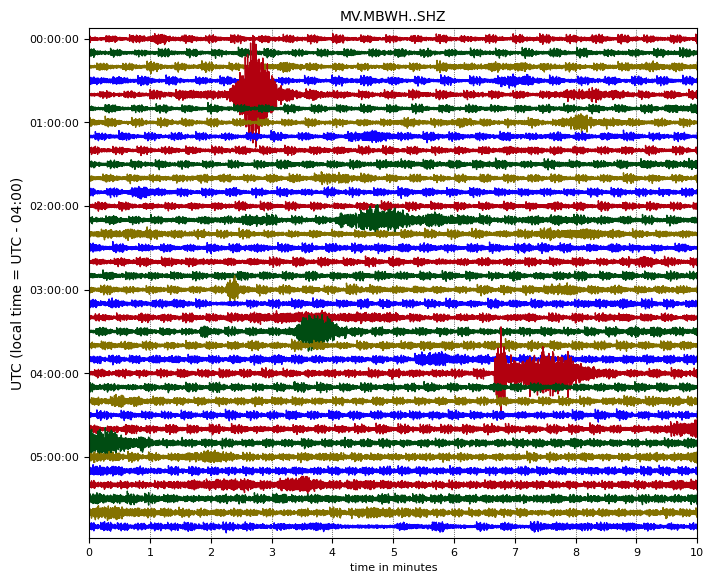

In [7]:
st = sdsclient.get_waveforms('MV',"MBWH","*","SHZ",obspy.UTCDateTime(2003, 7, 11, 0, 0, 0),obspy.UTCDateTime(2003, 7, 11, 6, 0, 0)   )
st.plot(type="dayplot", interval=10, vertical_scaling_range=3e3);


The strong repetition here is characteristic of **drumbeat seismicity**.


## 6. Optional: write the trace to audio

This cell is optional and platform-dependent. It is left here because it was
part of the original notebook and can still be useful for quick qualitative
inspection.


In [8]:

wav_audio_file = LOCAL_DATA_DIR / "MV20030711.wav"
st[0].write(str(wav_audio_file), rescale=True, format="WAV", framerate=6000 * 2)

print(f"Wrote {wav_audio_file}")


Wrote /Users/glennthompson/compsci/MV20030711.wav


## 7. Example 1 — inspect STA/LTA behaviour on one hour of data

We first look at one hour of data and inspect the STA/LTA characteristic
function on a single trace.


Number of traces in raw stream: 8


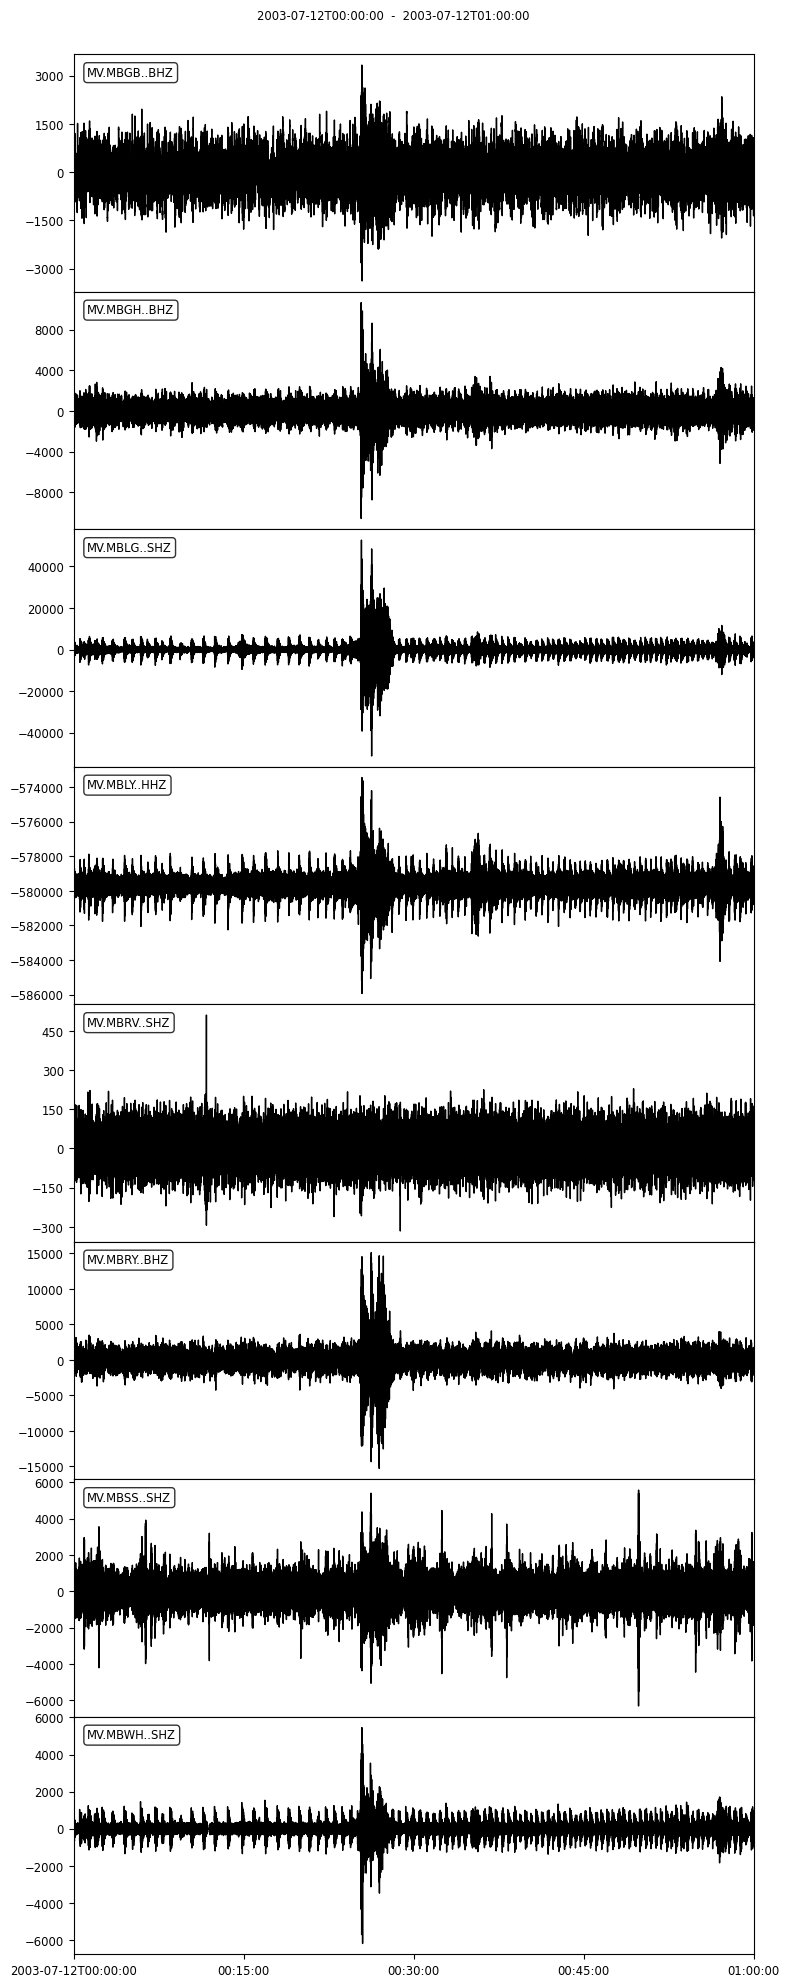

In [9]:

from obspy.signal.trigger import classic_sta_lta, plot_trigger

stime = obspy.UTCDateTime("2003193T")
etime = stime + 3600

st = sdsclient.get_waveforms('MV',"*","*","*Z", stime, etime )
st = drop_short_traces(st, max_secs)

print(f"Number of traces in raw stream: {len(st)}")
st.plot(equal_scale=False);


8 Trace(s) in Stream:
MV.MBGB..BHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
MV.MBGH..BHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
MV.MBLG..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
MV.MBLY..HHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 100.0 Hz, 360001 samples
MV.MBRV..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
MV.MBRY..BHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
MV.MBSS..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
MV.MBWH..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-12T01:00:00.000000Z | 75.0 Hz, 270001 samples
Trace selected: MV.MBWH..SHZ
Sampling rate: 75 Hz


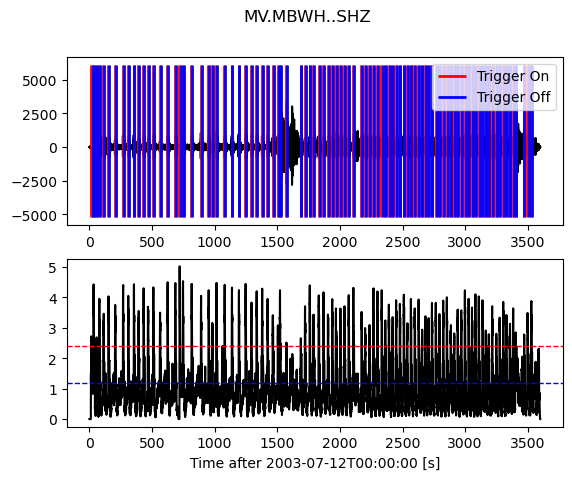

In [10]:

st_single = preprocess_detection_stream(st, freqmin=freqmin, freqmax=freqmax, corners=corners)
print(st_single)

tr_index = -1
tr = st_single[tr_index]

Fs = int(round(tr.stats.sampling_rate))
sta_samples = int(sta_secs * Fs)
lta_samples = int(lta_secs * Fs)

print(f"Trace selected: {tr.id}")
print(f"Sampling rate: {Fs} Hz")

cft = classic_sta_lta(tr.data, sta_samples, lta_samples)
plot_trigger(tr, cft, thresh_on, thresh_off)
plt.show()


The upper panel shows the waveform with trigger-on and trigger-off markers,
while the lower panel shows the STA/LTA ratio. This is still the quickest way
to check whether the chosen parameters are sensible on a representative trace.


## 8. Example 2 — detect coincident network events in one hour

Now we use the flovopy helpers to detect network events and immediately convert
the results into a dataframe.


In [11]:

st_det = preprocess_detection_stream(st, freqmin=freqmin, freqmax=freqmax, corners=corners)

trig, ontimes, offtimes = detect_network_event(
    st_det,
    minchans=thresh_stations,
    threshon=thresh_on,
    threshoff=thresh_off,
    sta=sta_secs,
    lta=lta_secs,
    algorithm="classicstalta",
    join_within=5.0,
    min_duration=0.5,
    verbose=False,
)

if trig is None:
    print("No triggers found.")
else:
    print(f"Number of network triggers: {len(trig)}")
    print("First trigger dictionary:")
    from pprint import pprint
    pprint(trig[0])


Number of network triggers: 91
First trigger dictionary:
{'cft_peak_wmean': 3.4419635791183567,
 'cft_peaks': [2.804654341806884,
               4.21362674735122,
               4.065007633747166,
               3.1310595685602167,
               2.7360618670882038,
               4.070119593464126,
               3.151693651226438,
               2.7153572722946056,
               2.8837541364764046,
               4.418691236177977,
               4.078770780960642,
               2.87987425271542,
               4.029185514521895,
               3.3415440396546,
               2.4619250933215575],
 'cluster_members': [{'duration': 14.919999957084656,
                      'time': UTCDateTime(2003, 7, 12, 0, 0, 11, 480000)},
                     {'duration': 11.133333206176758,
                      'time': UTCDateTime(2003, 7, 12, 0, 0, 29, 453333)}],
 'cluster_size': 2,
 'coincidence_sum': 8.0,
 'duration': 29.106667,
 'stations': ['MBLG', 'MBRY', 'MBRV', 'MBGH', 'MBGB', 'MBSS', 'M

In [12]:

if trig:
    event_df = extract_triggers_to_dataframe(
        st_det,
        trig,
        pretrigger_seconds=pretrig,
        posttrigger_seconds=posttrig,
        write_mseed=False,
        outdir=str(EVENTS_DIR),
        make_plots=False,
        filename_safe=True,
    )
else:
    event_df = pd.DataFrame()

summarize_detection_df(event_df)


Detected 91 events


,on_time,off_time,duration_s,coincidence_sum,snr_rms,n_seed_ids
0,2003-07-12 00:00:11.480000,2003-07-12 00:00:40.586667,29.106667,8.0,6.761018,8
1,2003-07-12 00:00:53.310000,2003-07-12 00:00:59.040000,5.730000,3.0,1.782824,8
2,2003-07-12 00:01:17.346667,2003-07-12 00:01:27.040000,9.693333,5.0,2.363656,8
3,2003-07-12 00:01:51.586667,2003-07-12 00:01:57.293334,5.706667,3.0,2.028260,8
4,2003-07-12 00:02:30.960000,2003-07-12 00:02:39.920000,8.960000,5.0,2.281519,8


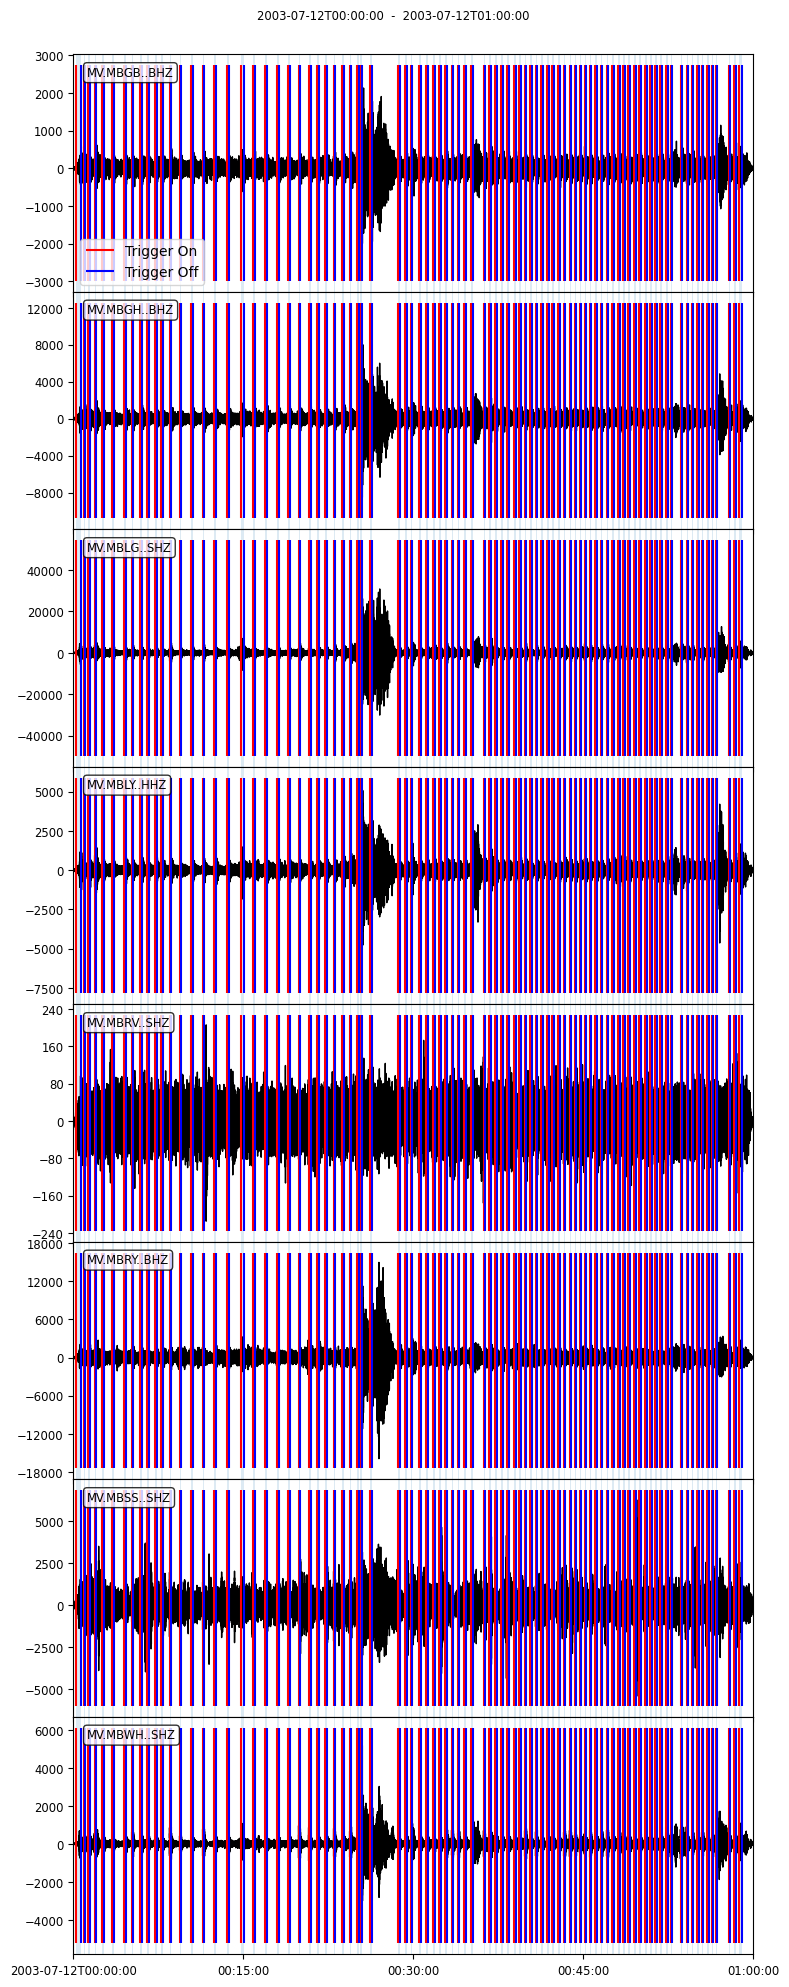

In [13]:

if len(event_df):
    _fig, _axes = plot_stream_with_event_markers(
        st_det,
        event_df,
        on_col="on_time",
        off_col="off_time",
        show=True,
        shade_events=True,
        equal_scale=False,
    )


### Filter the hourly detections

A dataframe-first workflow makes it easy to remove obvious weak or noisy
detections before exporting or aggregating them.


In [14]:

event_df_filt = filter_events_df(
    event_df,
    min_snr=1.2,
    min_duration_s=0.5,
    min_seed_ids=thresh_stations,
)

print(f"Raw detections:      {len(event_df)}")
print(f"Filtered detections: {len(event_df_filt)}")
display(event_df_filt.head())


Raw detections:      91
Filtered detections: 91


,event_index,on_time,off_time,duration_s,seed_ids,n_seed_ids,pretrigger_s,posttrigger_s,outdir,filename,...,wrote_file,coincidence_sum,signal_rms,noise_rms,snr_rms,stations,trace_ids,cft_peaks,cft_peak_wmean,cluster_size
0,0,2003-07-12 00:00:11.480000,2003-07-12 00:00:40.586667,29.106667,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000011.480000.mseed,...,False,8.0,249.770362,36.942717,6.761018,"[MBLG, MBRY, MBRV, MBGH, MBGB, MBSS, MBLY, MBWH]","[MV.MBLG..SHZ, MV.MBRY..BHZ, MV.MBRV..SHZ, MV....","[2.804654341806884, 4.21362674735122, 4.065007...",3.441964,2
1,1,2003-07-12 00:00:53.310000,2003-07-12 00:00:59.040000,5.730000,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000053.310000.mseed,...,False,3.0,552.322695,309.802212,1.782824,"[MBLY, MBSS, MBWH]","[MV.MBLY..HHZ, MV.MBSS..SHZ, MV.MBWH..SHZ]","[3.385533406806113, 3.242911033708121, 2.68177...",3.103408,1
2,2,2003-07-12 00:01:17.346667,2003-07-12 00:01:27.040000,9.693333,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000117.346667.mseed,...,False,5.0,518.398768,219.320754,2.363656,"[MBWH, MBLG, MBLY, MBGB, MBGH]","[MV.MBWH..SHZ, MV.MBLG..SHZ, MV.MBLY..HHZ, MV....","[3.9473559897121135, 3.8891739186517595, 4.031...",3.544813,1
3,3,2003-07-12 00:01:51.586667,2003-07-12 00:01:57.293334,5.706667,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000151.586667.mseed,...,False,3.0,431.772996,212.878529,2.028260,"[MBWH, MBLY, MBGH]","[MV.MBWH..SHZ, MV.MBLY..HHZ, MV.MBGH..BHZ]","[3.455386688057506, 3.650671018762348, 2.46197...",3.189344,1
4,4,2003-07-12 00:02:30.960000,2003-07-12 00:02:39.920000,8.960000,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000230.960000.mseed,...,False,5.0,429.255056,188.144385,2.281519,"[MBWH, MBLG, MBLY, MBGB, MBGH]","[MV.MBWH..SHZ, MV.MBLG..SHZ, MV.MBLY..HHZ, MV....","[4.028079969842647, 3.5778327701845196, 3.9289...",3.532731,1


### Optional: export the filtered events

This can write MiniSEED windows and quick-look PNGs for each detected event.


In [15]:

export_df = export_events_from_catalogue(
    event_df_filt,
    base_outdir=str(EVENTS_DIR / "example_hour"),
    write_mseed=False,
    write_png=False,
    st_continuous=st_det,
)

display(export_df.head())


,event_index,on_time,off_time,duration_s,seed_ids,n_seed_ids,pretrigger_s,posttrigger_s,outdir,filename,...,noise_rms,snr_rms,stations,trace_ids,cft_peaks,cft_peak_wmean,cluster_size,export_dir,export_mseed_path,export_png_path
0,0,2003-07-12 00:00:11.480000,2003-07-12 00:00:40.586667,29.106667,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000011.480000.mseed,...,36.942717,6.761018,"[MBLG, MBRY, MBRV, MBGH, MBGB, MBSS, MBLY, MBWH]","[MV.MBLG..SHZ, MV.MBRY..BHZ, MV.MBRV..SHZ, MV....","[2.804654341806884, 4.21362674735122, 4.065007...",3.441964,2,/Users/glennthompson/compsci/events/example_ho...,,
1,1,2003-07-12 00:00:53.310000,2003-07-12 00:00:59.040000,5.730000,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000053.310000.mseed,...,309.802212,1.782824,"[MBLY, MBSS, MBWH]","[MV.MBLY..HHZ, MV.MBSS..SHZ, MV.MBWH..SHZ]","[3.385533406806113, 3.242911033708121, 2.68177...",3.103408,1,/Users/glennthompson/compsci/events/example_ho...,,
2,2,2003-07-12 00:01:17.346667,2003-07-12 00:01:27.040000,9.693333,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000117.346667.mseed,...,219.320754,2.363656,"[MBWH, MBLG, MBLY, MBGB, MBGH]","[MV.MBWH..SHZ, MV.MBLG..SHZ, MV.MBLY..HHZ, MV....","[3.9473559897121135, 3.8891739186517595, 4.031...",3.544813,1,/Users/glennthompson/compsci/events/example_ho...,,
3,3,2003-07-12 00:01:51.586667,2003-07-12 00:01:57.293334,5.706667,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000151.586667.mseed,...,212.878529,2.028260,"[MBWH, MBLY, MBGH]","[MV.MBWH..SHZ, MV.MBLY..HHZ, MV.MBGH..BHZ]","[3.455386688057506, 3.650671018762348, 2.46197...",3.189344,1,/Users/glennthompson/compsci/events/example_ho...,,
4,4,2003-07-12 00:02:30.960000,2003-07-12 00:02:39.920000,8.960000,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",8,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-12T000230.960000.mseed,...,188.144385,2.281519,"[MBWH, MBLG, MBLY, MBGB, MBGH]","[MV.MBWH..SHZ, MV.MBLG..SHZ, MV.MBLY..HHZ, MV....","[4.028079969842647, 3.5778327701845196, 3.9289...",3.532731,1,/Users/glennthompson/compsci/events/example_ho...,,


### Plot event rate for the one-hour example


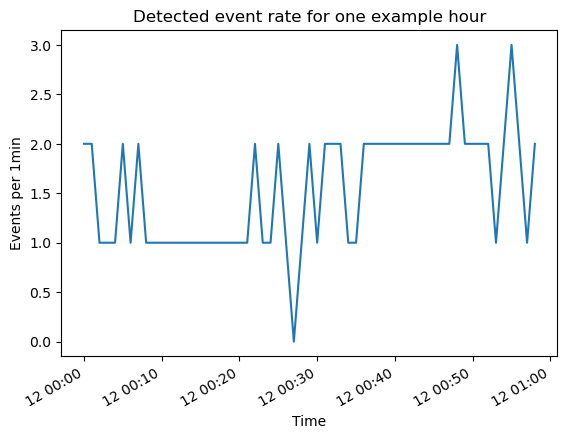

In [16]:

plot_event_rate(
    event_df_filt,
    bin_size="1min",
    title="Detected event rate for one example hour",
    show=True,
);


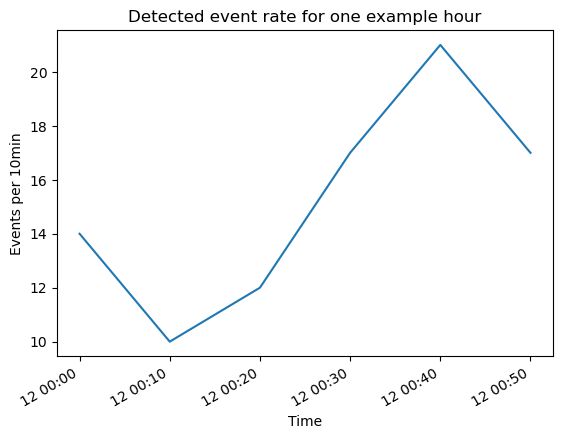

In [17]:

plot_event_rate(
    event_df_filt,
    bin_size="10min",
    title="Detected event rate for one example hour",
    show=True,
);


## 9. Example 3 — run coincidence triggering over multiple days

The original notebook looped over each hour, created a catalog object, wrote
event files, and concatenated catalogs. Here we keep the same basic loop, but
we collect per-hour dataframes and concatenate them at the end.


In [ ]:

# Detection settings for the multi-day run
jday_start = 184
jday_stop = 195   # stop is exclusive, so this covers days 190-196
hourly_catalogues = []

for jday in range(jday_start, jday_stop):
    print(f"Julian day {jday}: ", end="")
    for hour in range(24):
        stime = obspy.UTCDateTime(f"2003{jday}T") + hour * 3600
        etime = stime + 3600
        print(f"{hour:02d}", end=" " if hour < 23 else "\n")

        st = sdsclient.get_waveforms('MV', "*", "*", "*Z", stime - 60, etime + 60)
        if len(st) == 0:
            continue

        st = drop_short_traces(st, max_secs)
        if len(st) == 0:
            continue

        st_det = preprocess_detection_stream(
            st,
            freqmin=freqmin,
            freqmax=freqmax,
            corners=corners,
            starttime=stime,
            endtime=etime,
        )

        if len(st_det) == 0:
            continue

        df_hour = detect_events_for_window(
            st_det,
            threshold_on=thresh_on,
            threshold_off=thresh_off,
            sta_seconds=sta_secs,
            lta_seconds=lta_secs,
            min_channels=thresh_stations,
            pretrigger_seconds=pretrig,
            posttrigger_seconds=posttrig,
            outdir=EVENTS_DIR,
            write_mseed=False,
        )

        if len(df_hour):
            df_hour = df_hour.copy()
            df_hour["window_start"] = pd.Timestamp(stime.datetime)
            df_hour["jday"] = jday
            df_hour["hour"] = hour
            hourly_catalogues.append(df_hour)

if hourly_catalogues:
    catalog_df = pd.concat(hourly_catalogues, ignore_index=True)
else:
    catalog_df = pd.DataFrame()

print(f"Total detected events: {len(catalog_df)}")


Julian day 184: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 185: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 186: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 187: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 188: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 189: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 190: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 191: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 192: 00 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23
Julian day 193: 00 01 

Exception: ERROR 1 stalta: len(data) < nlta

## 10. Inspect the combined dataframe


In [21]:

if len(catalog_df):
    display(catalog_df.head())
    print(catalog_df.dtypes)
else:
    print("catalog_df is empty")


,event_index,on_time,off_time,duration_s,seed_ids,n_seed_ids,pretrigger_s,posttrigger_s,outdir,filename,...,noise_rms,snr_rms,stations,trace_ids,cft_peaks,cft_peak_wmean,cluster_size,window_start,jday,hour
0,0,2003-07-09 00:10:52.453333,2003-07-09 00:11:03.706667,11.253333,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",7,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-09T001052.453333.mseed,...,247.530227,6.031770,"[MBSS, MBLY, MBLG, MBRY, MBGH, MBGB]","[MV.MBSS..SHZ, MV.MBLY..HHZ, MV.MBLG..SHZ, MV....","[2.961745631091138, 4.851002594430149, 4.20891...",4.038868,None,2003-07-09 00:00:00,190,0
1,1,2003-07-09 00:17:47.640000,2003-07-09 00:18:11.880000,24.240000,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",7,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-09T001747.640000.mseed,...,277.202058,12.712975,"[MBRY, MBLG, MBLY, MBGH, MBGB, MBSS, MBRV]","[MV.MBRY..BHZ, MV.MBLG..SHZ, MV.MBLY..HHZ, MV....","[3.4907421686075324, 4.1540572912173115, 3.978...",3.505320,None,2003-07-09 00:00:00,190,0
2,2,2003-07-09 00:38:13.420000,2003-07-09 00:38:34.093333,20.673333,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",7,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-09T003813.420000.mseed,...,300.355752,3.435009,"[MBLY, MBRY, MBLG, MBGH, MBGB]","[MV.MBLY..HHZ, MV.MBRY..BHZ, MV.MBLG..SHZ, MV....","[3.2334193736586943, 3.5332646703227217, 3.687...",3.331937,None,2003-07-09 00:00:00,190,0
3,3,2003-07-09 00:40:00.480000,2003-07-09 00:40:16.920000,16.440000,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",7,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-09T004000.480000.mseed,...,398.373677,2.186439,"[MBSS, MBLY, MBGH, MBLG, MBGB, MBRY, MBRV]","[MV.MBSS..SHZ, MV.MBLY..HHZ, MV.MBGH..BHZ, MV....","[2.4175723655338555, 3.1155334169666293, 2.771...",2.776268,None,2003-07-09 00:00:00,190,0
4,0,2003-07-09 01:16:26.410000,2003-07-09 01:16:30.586667,4.176667,"[MV.MBGB..BHZ, MV.MBGH..BHZ, MV.MBLG..SHZ, MV....",7,10.0,20.0,/Users/glennthompson/compsci/events,2003-07-09T011626.410000.mseed,...,226.619581,1.663944,"[MBLY, MBGB, MBGH]","[MV.MBLY..HHZ, MV.MBGB..BHZ, MV.MBGH..BHZ]","[2.9593879649689754, 2.419095469148395, 2.4433...",2.607262,None,2003-07-09 01:00:00,190,1


event_index                 int64
on_time            datetime64[ns]
off_time           datetime64[ns]
duration_s                float64
seed_ids                   object
n_seed_ids                  int64
pretrigger_s              float64
posttrigger_s             float64
outdir                     object
filename                   object
filepath                   object
wrote_file                   bool
coincidence_sum           float64
signal_rms                float64
noise_rms                 float64
snr_rms                   float64
stations                   object
trace_ids                  object
cft_peaks                  object
cft_peak_wmean            float64
cluster_size               object
window_start       datetime64[us]
jday                        int64
hour                        int64
dtype: object


The old notebook used a custom catalog object. In this refactored version,
`catalog_df` is now the main catalogue product. It is easier to filter, save,
reload, and pass into later notebooks.


## 11. Save the combined catalogue

Because the current workflow is dataframe-based, we save the detections as CSV
and Pickle rather than as the older custom event catalog / QuakeML object.


In [22]:

csv_path = CATALOG_DIR / "catalog_MV_20030712_flovopy.csv"
pkl_path = CATALOG_DIR / "catalog_MV_20030712_flovopy.pkl"

catalog_df.to_csv(csv_path, index=False)
catalog_df.to_pickle(pkl_path)

print(csv_path)
print(pkl_path)
print(list(CATALOG_DIR.iterdir()))


/Users/glennthompson/compsci/catalogs/catalog_MV_20030712_flovopy.csv
/Users/glennthompson/compsci/catalogs/catalog_MV_20030712_flovopy.pkl
[PosixPath('/Users/glennthompson/compsci/catalogs/catalog_MV_20030712_flovopy.csv'), PosixPath('/Users/glennthompson/compsci/catalogs/catalog_MV_20030712_flovopy.pkl')]


## 12. Plot the event catalogue

These plots replace the old `catalogObj.plot_eventrate(...)` workflow.


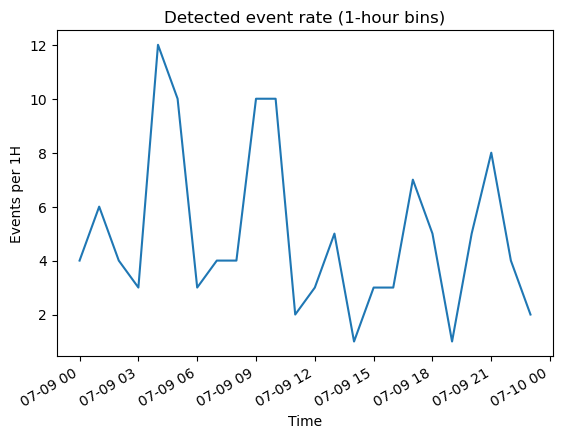

In [23]:

plot_event_rate(
    catalog_df,
    bin_size="1H",
    title="Detected event rate (1-hour bins)",
    show=True,
);


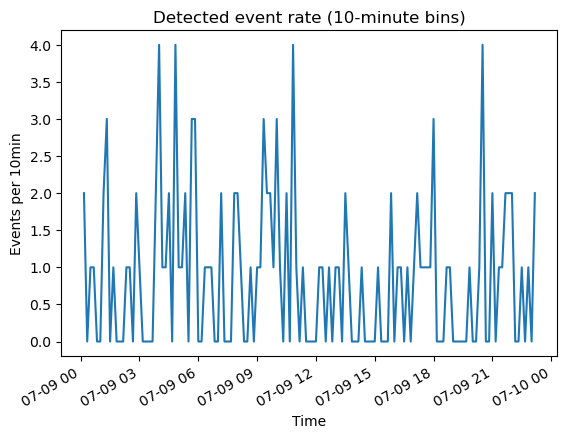

In [24]:

plot_event_rate(
    catalog_df,
    bin_size="10min",
    title="Detected event rate (10-minute bins)",
    show=True,
);


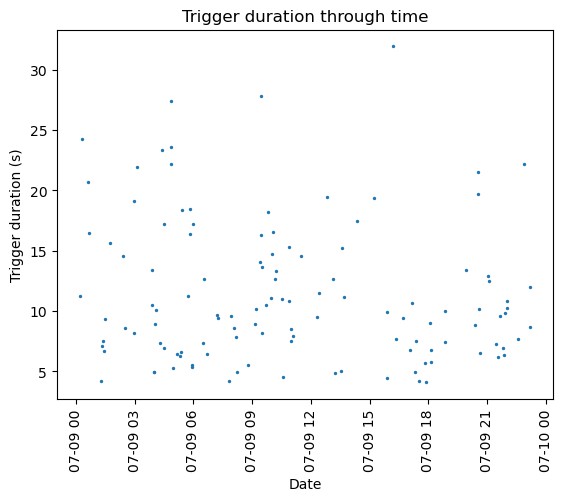

In [25]:

catalog_df.plot.scatter(
    x="on_time",
    y="duration_s",
    s=2,
    rot=90,
    xlabel="Date",
    ylabel="Trigger duration (s)",
    title="Trigger duration through time",
);
plt.show()


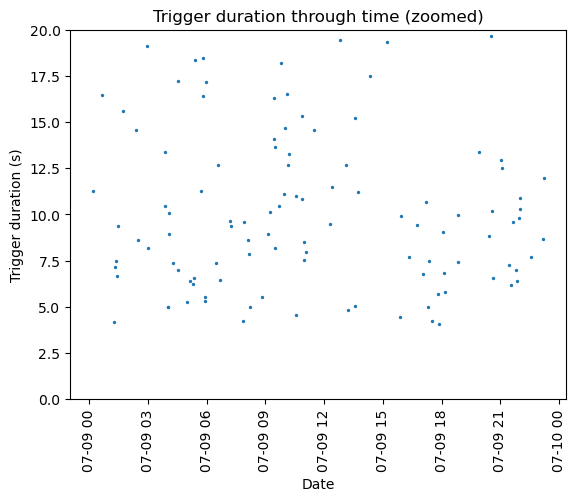

In [26]:

ax = catalog_df.plot.scatter(
    x="on_time",
    y="duration_s",
    s=2,
    rot=90,
    xlabel="Date",
    ylabel="Trigger duration (s)",
    title="Trigger duration through time (zoomed)",
)
ax.set_ylim([0, 20])
plt.show()


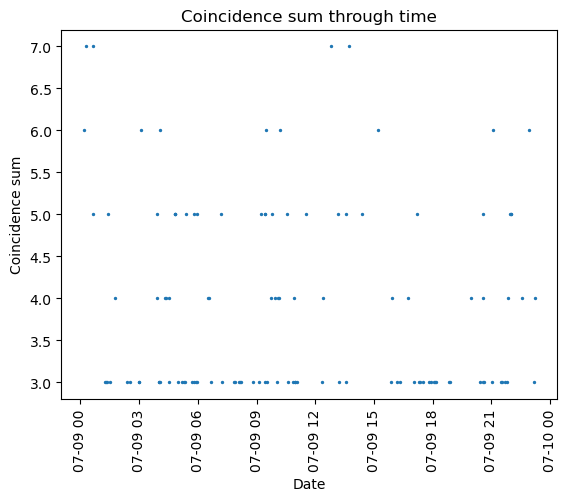

In [27]:

if "coincidence_sum" in catalog_df.columns:
    ax = catalog_df.plot.scatter(
        x="on_time",
        y="coincidence_sum",
        s=2,
        rot=90,
        xlabel="Date",
        ylabel="Coincidence sum",
        title="Coincidence sum through time",
    )
    plt.show()


In the legacy notebook, the custom event catalog also exposed a crude magnitude.
The dataframe workflow provided by `flovopy.processing.detection` does **not**
currently build that same catalog-object magnitude field, so this notebook
focuses on directly available measures such as:

- trigger duration
- RMS-based SNR
- number of contributing traces
- coincidence sum


## 13. Inspect a period of elevated activity

This reproduces the original qualitative inspection step on a time window where
activity increases strongly.


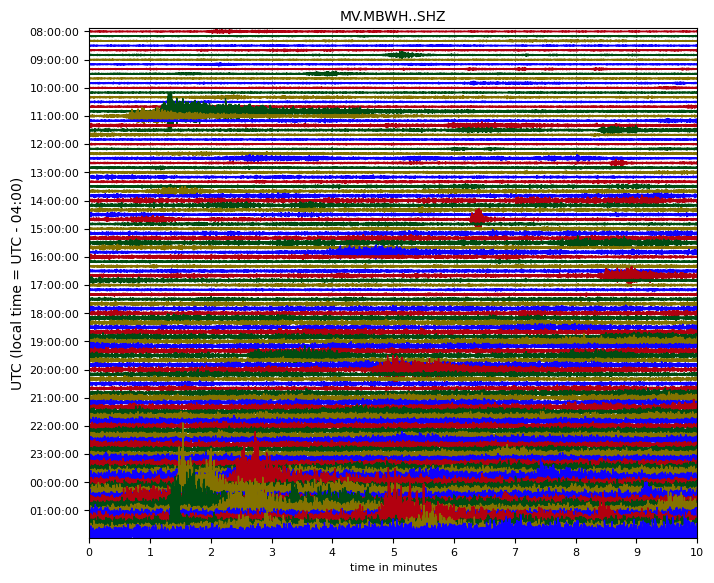

In [28]:
st2 = sdsclient.get_waveforms("MV", "MBWH", "*", "SHZ", obspy.UTCDateTime(2003, 7, 12, 8, 0, 0), obspy.UTCDateTime(2003, 7, 13, 2, 0, 0))
st2.plot(type="dayplot", interval=10, vertical_scaling_range=8e3);


## 14. Zoom in on the event-rate plot

Because we now store detections in a dataframe, time filtering is done with
ordinary pandas logic.


In [29]:

time_min = pd.Timestamp(2003, 7, 12, 0, 0, 0)
time_max = pd.Timestamp(2003, 7, 14, 12, 0, 0)

catalog_zoom = catalog_df[
    (pd.to_datetime(catalog_df["on_time"]) >= time_min)
    & (pd.to_datetime(catalog_df["on_time"]) <= time_max)
].copy()

plot_event_rate(
    catalog_zoom,
    bin_size="10min",
    title="Detected event rate (zoomed window)",
    show=True,
);


No events after filtering.


## 15. Suggested next steps

This notebook now gives you a clean `flovopy`-based event-detection workflow.
A natural follow-on notebook could add:

1. event classification
2. phase picking
3. improved magnitude or energy measures
4. event family similarity / template matching
5. conversion of the dataframe catalogue into a richer ObsPy `Catalog` if you decide you want that later
